# Diabetes Prediction Project

## Introduction

The goal of this project is to predict whether a patient has diabetes based on medical measurements.

This is a binary classification problem:
- 0 = no diabetes
- 1 = diabetes

This notebook includes:
- dataset description
- exploratory data analysis
- data cleaning
- model comparison
- final model evaluation
- conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# 1. Dataset Description

The dataset contains medical information about patients and a target variable called `Outcome`.

Main features:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

Target:
- `Outcome = 0` means the patient does not have diabetes
- `Outcome = 1` means the patient has diabetes

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# 2. Exploratory Data Analysis (EDA)

In this section, the main characteristics of the dataset are explored through visualizations and descriptive analysis.

In [7]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

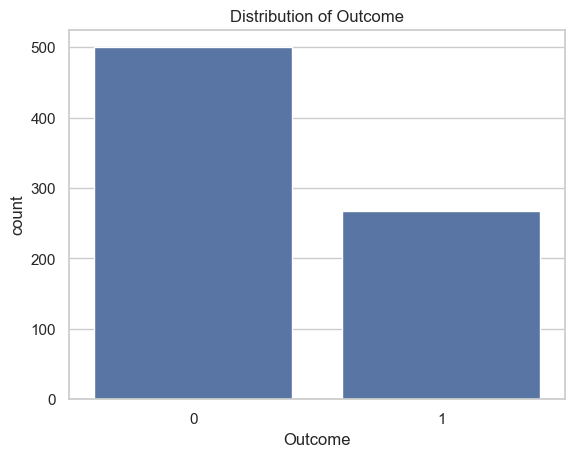

In [8]:
sns.countplot(data=df, x="Outcome")
plt.title("Distribution of Outcome")
plt.show()

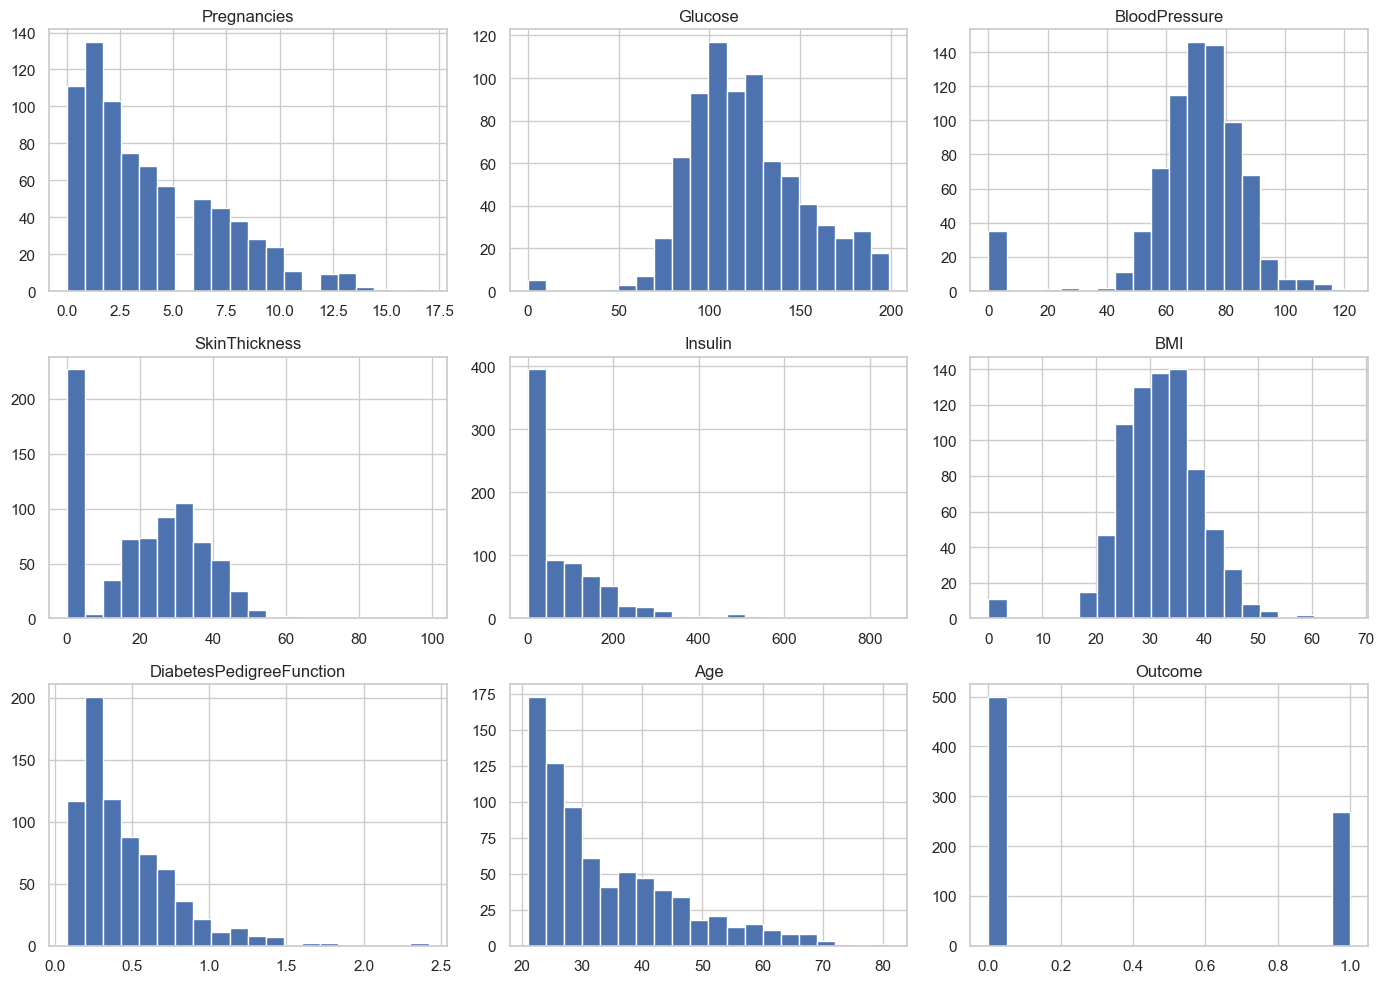

In [9]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

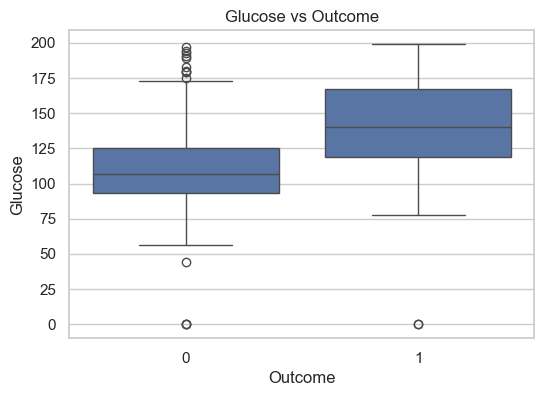

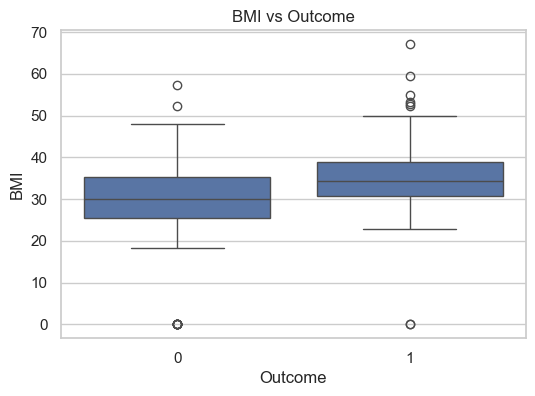

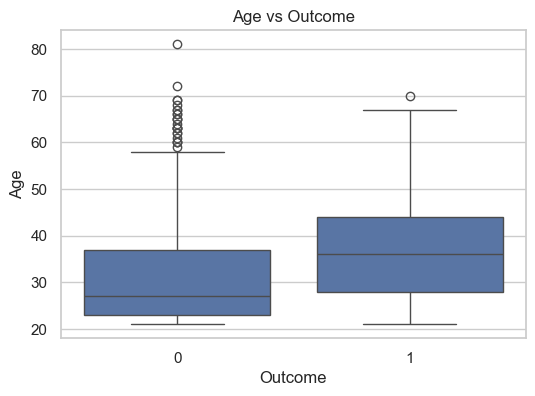

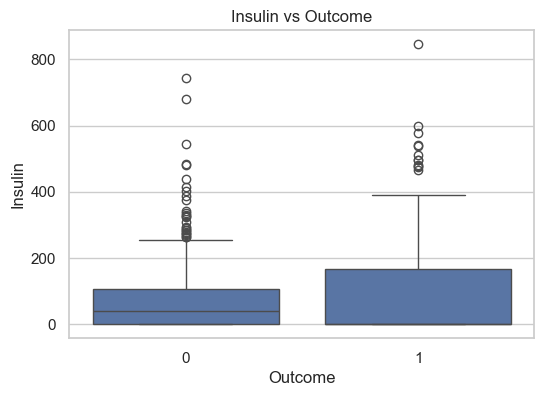

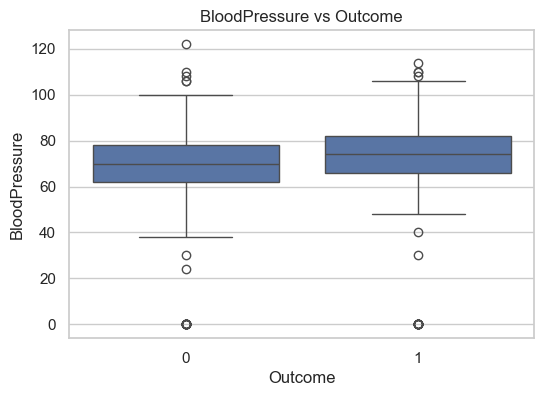

In [10]:
important_cols = ["Glucose", "BMI", "Age", "Insulin", "BloodPressure"]

for col in important_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Outcome", y=col)
    plt.title(f"{col} vs Outcome")
    plt.show()

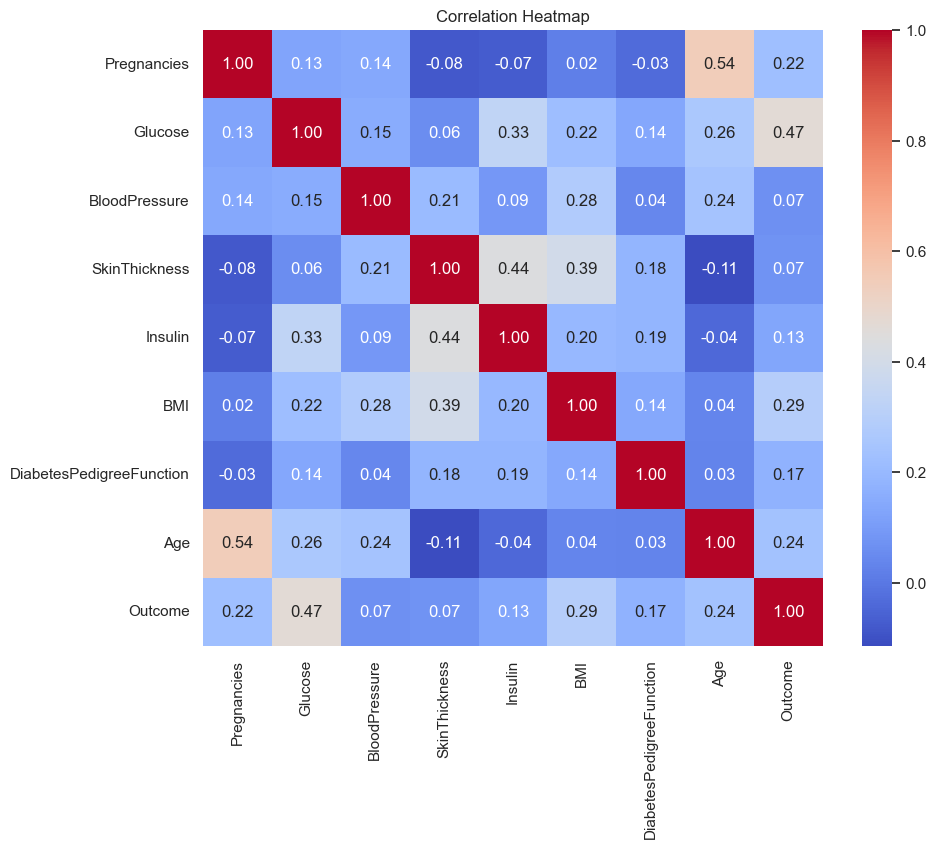

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## EDA Observations

From the exploratory data analysis, the following observations can be made:

- The dataset contains both diabetic and non-diabetic patients.
- Glucose appears to be strongly related to diabetes.
- BMI and Age also seem relevant for prediction.
- Some variables contain zero values that are not realistic in a medical context.

# 3. Data Cleaning

Some medical variables contain zero values that are not realistic.
These values will be treated as invalid and replaced with missing values.

In [12]:
zero_not_valid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_not_valid:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [13]:
df_clean = df.copy()

for col in zero_not_valid:
    df_clean[col] = df_clean[col].replace(0, np.nan)

df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Invalid zero values were replaced with `NaN` because measurements such as glucose, BMI, insulin, and blood pressure cannot realistically be zero.

These missing values will be handled later using imputation.

In [14]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

# 4. Train-Test Split

The dataset is divided into training and testing sets.
Stratified sampling is used in order to preserve the class distribution.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Experiments (Model Comparison)

Several classification algorithms are tested and compared.

The goal is to identify the model with the best predictive performance.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

## Experiment Justification

Multiple models were tested in order to compare different approaches for binary classification.

The F1-score was selected as the main evaluation metric because it balances precision and recall, which is important in medical prediction problems.

In [17]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="f1")
    
    results.append({
        "Model": name,
        "F1-score": scores.mean()
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
results_df

,Model,F1-score
0,Logistic Regression,0.649686
3,Random Forest,0.640476
4,SVM,0.622974
1,KNN,0.621366
2,Decision Tree,0.549891


The comparison shows that Logistic Regression achieved the highest F1-score among the tested models.

Therefore, it was selected as the final model for evaluation on the test set.

In [18]:
final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

# 7. Model Evaluation


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-score: 0.5454545454545454

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



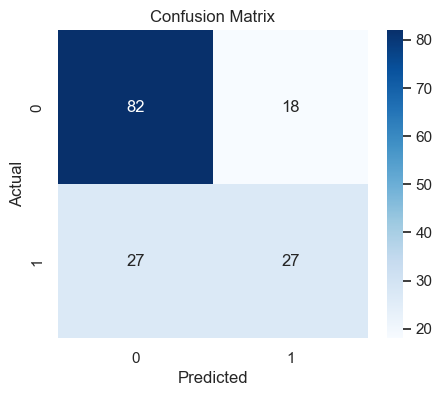

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The final evaluation shows the quality of the selected model on unseen data.

The confusion matrix highlights the number of correct and incorrect predictions, while the classification report summarizes the model performance in terms of precision, recall, and F1-score.

# 8. Conclusions

In this project, a machine learning workflow was developed for diabetes prediction using tabular medical data.

Main conclusions:
- Glucose was one of the strongest indicators of diabetes.
- BMI and Age also contributed to the prediction task.
- Invalid zero values had to be treated as missing values.
- Multiple models were tested and compared.
- Logistic Regression achieved the best overall performance based on the F1-score.

# 9. Comparison with Literature

This workflow is consistent with common machine learning tutorials and educational materials built on the Pima Indians Diabetes dataset.

Logistic Regression is frequently used as a baseline model for this dataset, and in this project it also achieved the best result among the tested algorithms.

Future work could include hyperparameter tuning and testing more advanced ensemble models.